<a href="https://colab.research.google.com/github/NidhiDekate/car-price-multimodal-dl/blob/main/07_explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import pickle
import scipy.io
import shutil
import random
import cv2

from sklearn.metrics import r2_score
import shap

base      = '/content/drive/MyDrive/CarPricePrediction/'
local_img = '/content/cars_train/'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device:", device)

# load data
X_train = np.load(base + 'data/tabular/X_train.npy')
X_val   = np.load(base + 'data/tabular/X_val.npy')
y_train = np.load(base + 'data/tabular/y_train.npy')
y_val   = np.load(base + 'data/tabular/y_val.npy')

# load xgboost model
with open(base + 'models/xgb_best.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

print("xgb model loaded")
print(f"X_val shape: {X_val.shape}")

Mounted at /content/drive
device: cuda
xgb model loaded
X_val shape: (6050, 12)


In [ ]:
os.makedirs(base + 'outputs/', exist_ok=True)
print("outputs folder ready")

outputs folder ready


shap values shape: (6050, 12)


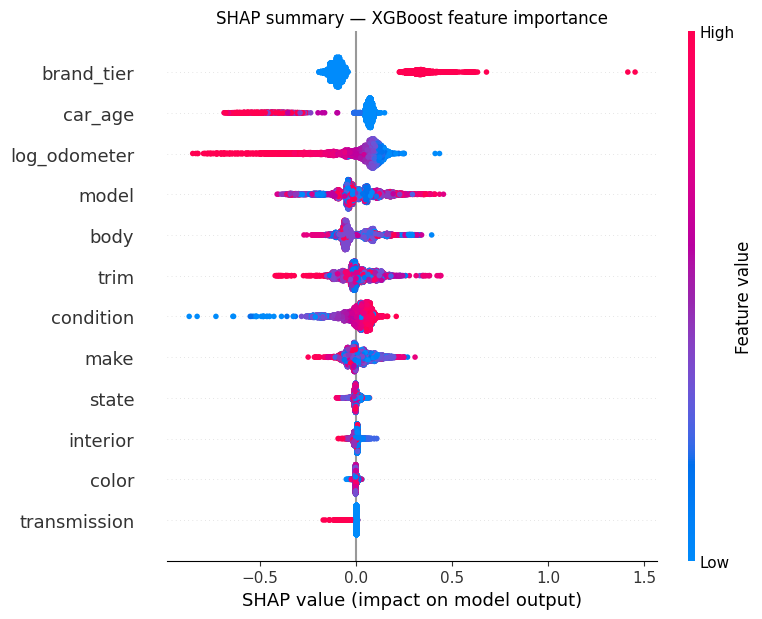

saved shap_summary.png


In [ ]:
feature_names = [
    'car_age', 'log_odometer', 'condition', 'brand_tier',
    'make', 'model', 'trim', 'body', 'transmission',
    'state', 'color', 'interior'
]

# shap explainer for xgboost
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_val)

print("shap values shape:", shap_values.shape)

# summary plot - shows feature importance + direction
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_val,
    feature_names=feature_names,
    show=False
)
plt.title("SHAP summary — XGBoost feature importance")
plt.tight_layout()
plt.savefig(base + 'outputs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved shap_summary.png")

In [ ]:
# copy images to local disk
if not os.path.exists(local_img):
    print("copying images...")
    shutil.copytree(base + 'data/images/cars_train/cars_train/', local_img)
    print("done!")
else:
    print("images already on local disk")

# rebuild class→image lookup
img_dir     = base + 'data/images/'
devkit_path = img_dir + 'car_devkit/'

meta        = scipy.io.loadmat(devkit_path + 'devkit/cars_meta.mat')
class_names = [str(c[0]) for c in meta['class_names'][0]]

train_annos = scipy.io.loadmat(devkit_path + 'devkit/cars_train_annos.mat')

class_to_images = {}
for anno in train_annos['annotations'][0]:
    class_idx = int(anno[4][0][0])
    filename  = str(anno[5][0])
    img_path  = local_img + filename
    if class_idx not in class_to_images:
        class_to_images[class_idx] = []
    class_to_images[class_idx].append(img_path)

classname_to_images = {}
for class_idx, img_paths in class_to_images.items():
    name = class_names[class_idx - 1]
    classname_to_images[name] = img_paths

print(f"classes mapped: {len(classname_to_images)}")

copying images...
done!
classes mapped: 196


In [ ]:
def build_cnn_model():
    model = models.resnet18(weights='IMAGENET1K_V1')
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Sequential(
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 1)
    )
    return model

cnn_model = build_cnn_model().to(device)
cnn_model.load_state_dict(torch.load(base + 'models/cnn_best.pth'))
cnn_model.eval()
print("CNN model loaded")

# Grad-CAM hook
class GradCAM:
    def __init__(self, model):
        self.model       = model
        self.gradients   = None
        self.activations = None

        # hook into layer4 - last conv block of resnet18
        target_layer = model.layer4
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, image_tensor):
        self.model.zero_grad()
        output = self.model(image_tensor)
        output.backward()

        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = torch.relu(cam)
        cam     = cam - cam.min()
        cam     = cam / (cam.max() + 1e-8)

        return cam.squeeze().cpu().numpy()

gradcam = GradCAM(cnn_model)
print(" ready")

CNN model loaded
 ready


In [ ]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# pick 6 random classes from our dataset
df_final  = pd.read_csv(base + 'data/tabular/df_final.csv')
sample_classes = random.sample(list(df_final['stanford_class'].unique()), 6)

fig, axes = plt.subplots(6, 2, figsize=(10, 24))

for i, class_name in enumerate(sample_classes):
    # pick random image from class
    img_path = random.choice(classname_to_images[class_name])
    orig_img = Image.open(img_path).convert('RGB')

    # transform for model
    img_tensor = val_transform(orig_img).unsqueeze(0).to(device)
    img_tensor.requires_grad = True

    # generate grad-cam
    cam = gradcam.generate(img_tensor)

    # resize cam to image size
    cam_resized = np.array(Image.fromarray(cam).resize(
        (orig_img.width, orig_img.height), Image.BILINEAR
    ))

    # create heatmap overlay
    heatmap    = cm.jet(cam_resized)[:, :, :3]
    orig_array = np.array(orig_img) / 255.0
    overlay    = 0.5 * orig_array + 0.5 * heatmap

    # get prediction
    with torch.no_grad():
        log_pred = cnn_model(val_transform(orig_img).unsqueeze(0).to(device))
        pred_price = np.expm1(log_pred.item())

    # plot original
    axes[i, 0].imshow(orig_img)
    axes[i, 0].set_title(f"{class_name}", fontsize=9)
    axes[i, 0].axis('off')

    # plot grad-cam
    axes[i, 1].imshow(overlay)
    axes[i, 1].set_title(f"Grad-CAM  |  pred: ${pred_price:,.0f}", fontsize=9)
    axes[i, 1].axis('off')

plt.suptitle("Grad-CAM — where CNN looks when predicting price", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(base + 'outputs/gradcam.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved gradcam.png")

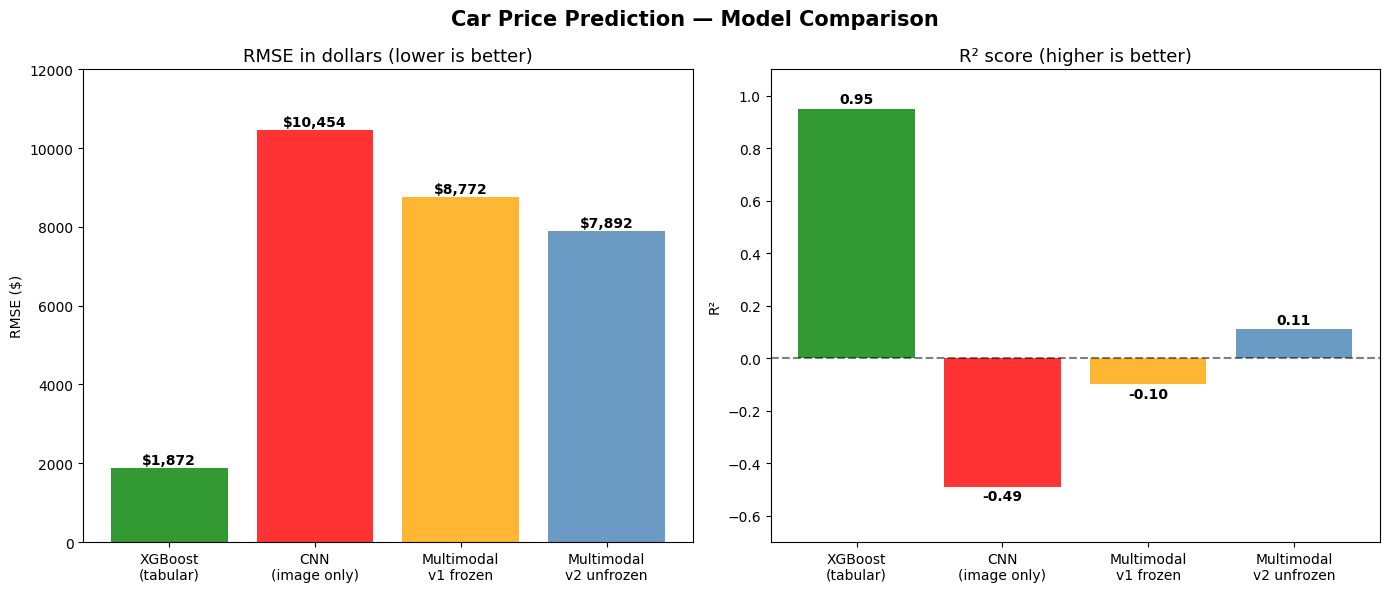

saved model_comparison.png


In [ ]:
# final model comparison plot
models_names = ['XGBoost\n(tabular)', 'CNN\n(image only)',
                'Multimodal\nv1 frozen', 'Multimodal\nv2 unfrozen']
rmses  = [1872, 10454, 8772, 7892]
r2s    = [0.95, -0.49, -0.10, 0.11]
colors = ['green', 'red', 'orange', 'steelblue']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# RMSE plot
bars1 = ax1.bar(models_names, rmses, color=colors, alpha=0.8)
ax1.set_title('RMSE in dollars (lower is better)', fontsize=13)
ax1.set_ylabel('RMSE ($)')
for bar, val in zip(bars1, rmses):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 100,
             f'${val:,}', ha='center', fontsize=10, fontweight='bold')
ax1.set_ylim(0, 12000)

# R² plot
bars2 = ax2.bar(models_names, r2s, color=colors, alpha=0.8)
ax2.set_title('R² score (higher is better)', fontsize=13)
ax2.set_ylabel('R²')
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
for bar, val in zip(bars2, r2s):
    ypos = val + 0.02 if val >= 0 else val - 0.05
    ax2.text(bar.get_x() + bar.get_width()/2, ypos,
             f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')
ax2.set_ylim(-0.7, 1.1)

plt.suptitle('Car Price Prediction — Model Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(base + 'outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved model_comparison.png")

In [ ]:

print("key findings:")
print("  1. brand_tier, car_age, log_odometer = top 3 price drivers (SHAP)")
print("  2. CNN focuses on car body/grille, ignores background (Grad-CAM)")
print("  3. XGBoost R²=0.95 — tabular features dominate price prediction")
print("  4. Multimodal improved with progressive unfreezing R²=-0.10 → 0.11")
print("  5. Real improvement needs per-listing unique car photos")

key findings:
  1. brand_tier, car_age, log_odometer = top 3 price drivers (SHAP)
  2. CNN focuses on car body/grille, ignores background (Grad-CAM)
  3. XGBoost R²=0.95 — tabular features dominate price prediction
  4. Multimodal improved with progressive unfreezing R²=-0.10 → 0.11
  5. Real improvement needs per-listing unique car photos
